Import Libraries


In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Load Dataset

In [2]:
(x_train,y_train), ( x_test,y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Normalizing Image

In [3]:
x_train= x_train/255.0
x_test=x_test/255.0


Data Augumentation

In [4]:
datagen =ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

Build CNN Model

In [5]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model Using Data Augumentation

In [10]:
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 139ms/step - accuracy: 0.5722 - loss: 1.2417 - val_accuracy: 0.6825 - val_loss: 0.9381
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.5882 - loss: 1.1872 - val_accuracy: 0.6850 - val_loss: 0.9108
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.5974 - loss: 1.1640 - val_accuracy: 0.6884 - val_loss: 0.9015
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 160ms/step - accuracy: 0.6043 - loss: 1.1440 - val_accuracy: 0.7071 - val_loss: 0.8558
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.6152 - loss: 1.1171 - val_accuracy: 0.7010 - val_loss: 0.8694
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6198 - loss: 1.1054 - val_accuracy: 0.6889 - val_loss: 0.9130
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 124ms/step - accuracy: 0.6223 - loss: 1.0972 - val_accuracy: 0.7130 - val_loss: 0.8245
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.6312 - 

Evaluate

In [12]:
test_loss,test_acc = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7198 - loss: 0.8178


Model Accuracy

In [13]:
print("Test Accuracy:",test_acc)

Test Accuracy: 0.7197999954223633


Plot Accuracy Graph

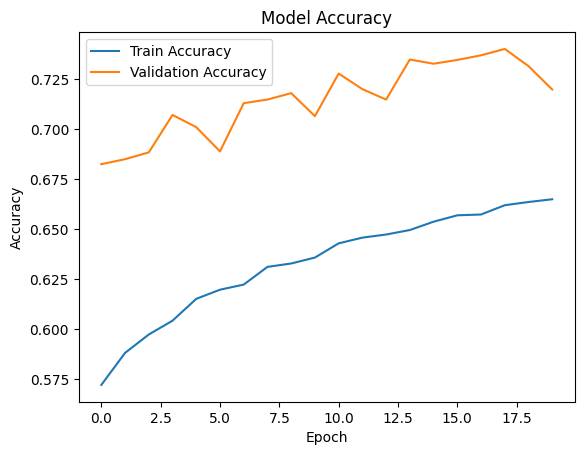

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train Accuracy","Validation Accuracy"])
plt.show()

Plot Loss Graph

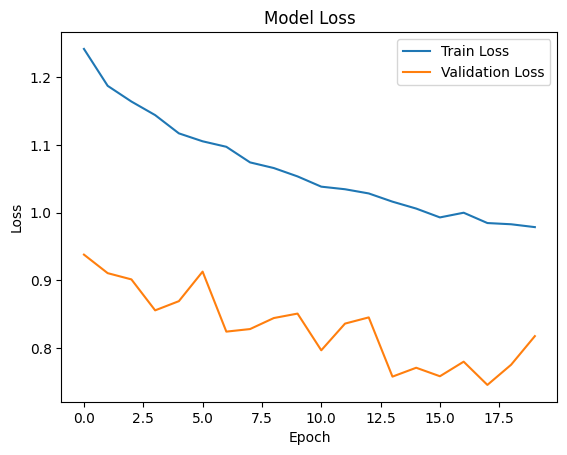

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train Loss","Validation Loss"])
plt.show()

Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


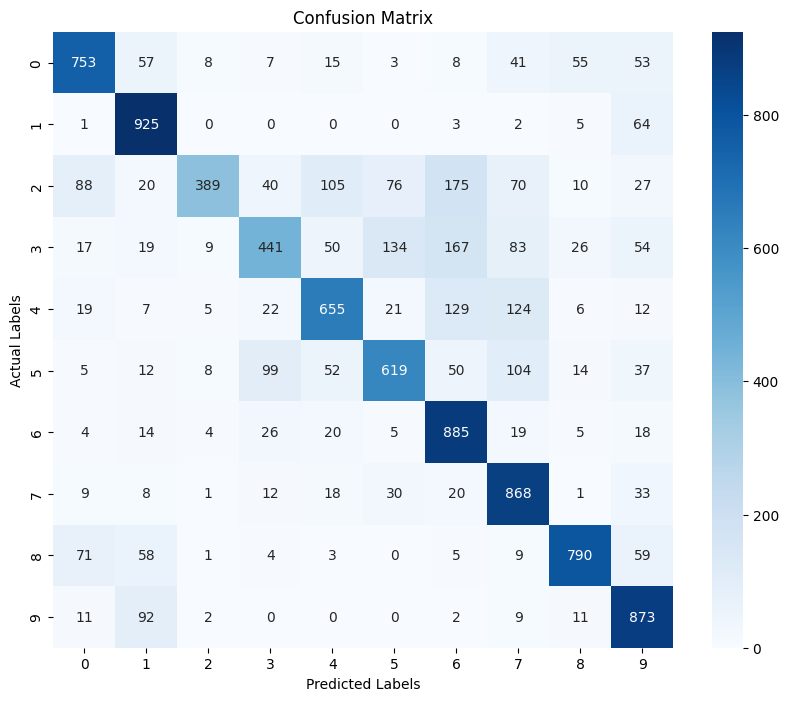

In [18]:
y_pred = model.predict(x_test)
y_pred_classes =np.argmax(y_pred,axis=1)

y_true = y_test.flatten()
cm = confusion_matrix(y_test,y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

Predicted vs Actual Images

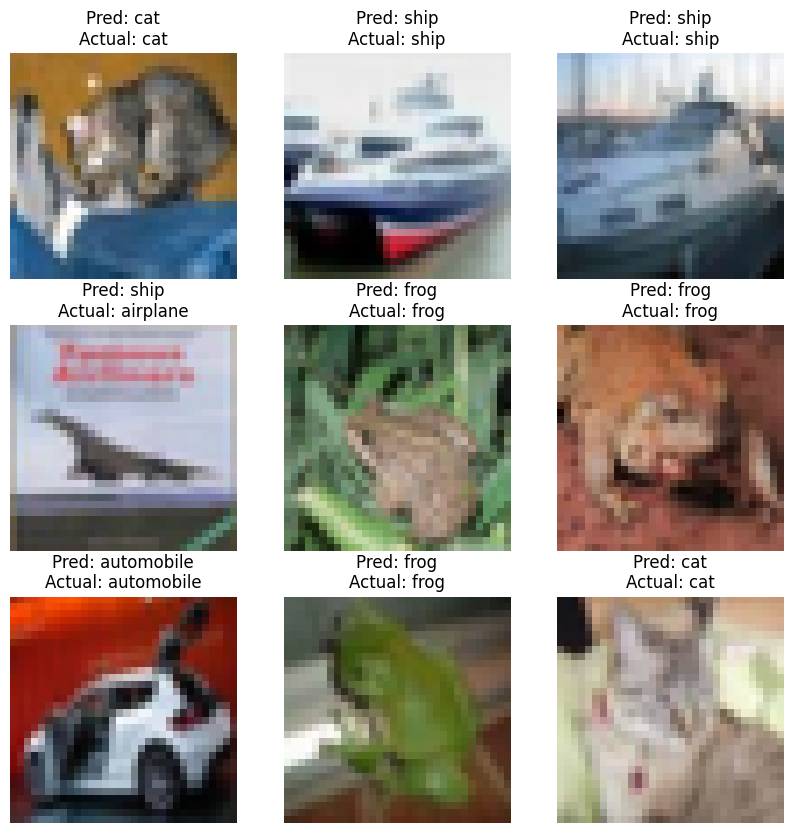

In [19]:
class_names= ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i])

    pred = class_names[y_pred_classes[i]]
    actual = class_names[y_test[i][0]]

    plt.title(f"Pred: {pred}\nActual: {actual}")

    plt.axis("off")

plt.show()